## Multi linear regression

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [130]:
path = "/home/silvy_linux/Desktop/Internship/Datasets/Housing.csv"

read_housing_data = pd.read_csv(path)
read_housing_data.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [131]:
read_housing_data.isnull().sum()   #no missing values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [132]:
duplicates = read_housing_data[read_housing_data.duplicated()]
print(duplicates)   #no duplicates

Empty DataFrame
Columns: [price, area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus]
Index: []


#### Performing Labeling encoding data

In [133]:
read_housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [134]:
read_housing_data["prefarea"].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [135]:
read_housing_data["mainroad"].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [136]:
read_housing_data["guestroom"].value_counts()

guestroom
no     448
yes     97
Name: count, dtype: int64

In [137]:
read_housing_data["basement"].value_counts()

basement
no     354
yes    191
Name: count, dtype: int64

In [138]:
read_housing_data["hotwaterheating"].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [139]:
read_housing_data["airconditioning"].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

In [140]:
label_encode = LabelEncoder()

In [141]:
yes_no_columns = ['prefarea', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning']

#columns we have to do label encoding

for col in yes_no_columns:
    read_housing_data[col] = label_encode.fit_transform(read_housing_data[col])

print(read_housing_data.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  


In [142]:
# read_housing_data.to_csv("sample_check.csv",index = False)  #to check 

In [143]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas')

In [144]:
ohetransform = ohe.fit_transform(read_housing_data[["furnishingstatus"]])

In [145]:
ohetransform

,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
540,0.0,0.0,1.0
541,0.0,1.0,0.0
542,0.0,0.0,1.0
543,1.0,0.0,0.0


In [146]:
read_housing_data = pd.concat([read_housing_data,ohetransform],axis='columns')

In [147]:
read_housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,1.0,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,1.0,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,0.0,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,1.0,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished,0.0,0.0,1.0
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished,0.0,1.0,0.0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished,0.0,0.0,1.0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished,1.0,0.0,0.0


In [148]:
read_housing_data.drop(['furnishingstatus'],axis='columns',inplace=True)

In [149]:
read_housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            545 non-null    int64  
 1   area                             545 non-null    int64  
 2   bedrooms                         545 non-null    int64  
 3   bathrooms                        545 non-null    int64  
 4   stories                          545 non-null    int64  
 5   mainroad                         545 non-null    int64  
 6   guestroom                        545 non-null    int64  
 7   basement                         545 non-null    int64  
 8   hotwaterheating                  545 non-null    int64  
 9   airconditioning                  545 non-null    int64  
 10  parking                          545 non-null    int64  
 11  prefarea                         545 non-null    int64  
 12  furnishingstatus_furnished       

In [150]:
read_housing_data = read_housing_data.astype({
    "furnishingstatus_furnished": int,
    "furnishingstatus_semi-furnished": int,
    "furnishingstatus_unfurnished": int
})  #convert the columns in float to int

In [151]:
read_housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_furnished       545 non-null    int64
 13  f

##### Performing mupliple linear regression

In [152]:
x = read_housing_data.drop('price',axis = 1)

In [153]:
y = read_housing_data['price']

In [154]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   area                             545 non-null    int64
 1   bedrooms                         545 non-null    int64
 2   bathrooms                        545 non-null    int64
 3   stories                          545 non-null    int64
 4   mainroad                         545 non-null    int64
 5   guestroom                        545 non-null    int64
 6   basement                         545 non-null    int64
 7   hotwaterheating                  545 non-null    int64
 8   airconditioning                  545 non-null    int64
 9   parking                          545 non-null    int64
 10  prefarea                         545 non-null    int64
 11  furnishingstatus_furnished       545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    int64
 13  f

In [155]:
x.describe()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
count,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.256881,0.416514,0.326606
std,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.437314,0.493434,0.469402
min,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [156]:
x.isnull().sum()

area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_furnished         0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

In [157]:
#dividing into training and test data

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [158]:
print(x.shape,x_train.shape,x_test.shape)

(545, 14) (436, 14) (109, 14)


In [159]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 436 entries, 46 to 102
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   area                             436 non-null    int64
 1   bedrooms                         436 non-null    int64
 2   bathrooms                        436 non-null    int64
 3   stories                          436 non-null    int64
 4   mainroad                         436 non-null    int64
 5   guestroom                        436 non-null    int64
 6   basement                         436 non-null    int64
 7   hotwaterheating                  436 non-null    int64
 8   airconditioning                  436 non-null    int64
 9   parking                          436 non-null    int64
 10  prefarea                         436 non-null    int64
 11  furnishingstatus_furnished       436 non-null    int64
 12  furnishingstatus_semi-furnished  436 non-null    int64
 13  furni

In [160]:
scalar = StandardScaler()

In [161]:
#fit and transform training data
x_train_scaled = scalar.fit_transform(x_train)

In [ ]:
#Transform testing data
x_test_scaled = scalar.fit_transform(x_test)

In [163]:
#create model 
model = LinearRegression()

In [164]:
#Train Model 

model.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [165]:
#prediction

y_pred = model.predict(x_test_scaled)

In [166]:
#compare actual vs predicted 

comparison = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})

comparison.head(10)

,Actual,Predicted
316,4060000,4.909907e+06
77,6650000,6.919606e+06
360,3710000,3.023066e+06
90,6440000,4.506479e+06
493,2800000,3.207161e+06
209,4900000,3.512776e+06
176,5250000,5.574648e+06
249,4543000,6.094435e+06
516,2450000,2.616438e+06
426,3353000,2.511353e+06


In [167]:
#Evaluation Model 

mse = mean_squared_error(y_test,y_pred)

mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print(mse,mae,rmse,r2)

1805574054959.9758 961213.1504944777 1343716.5084049448 0.6427838635222574


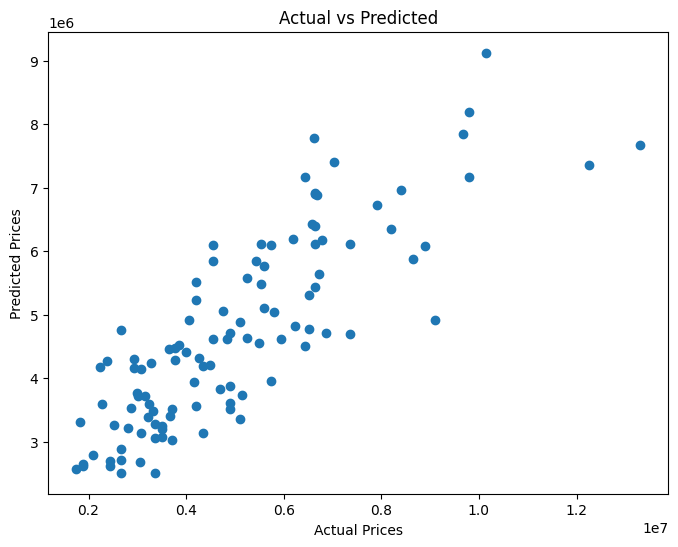

In [169]:
#Visualisation

plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")
plt.show()